In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.dummy import DummyRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.set_printoptions(precision=3, suppress=True)


In [2]:
df = pd.read_csv("housing.csv")
target_column_name = "median_house_value"
feature_column_names = [col for col in df.columns if col != target_column_name]

X_full = df[feature_column_names]
y_full = df[target_column_name]

display(df.head())
# Noterar att ocean_proximity inte är numerisk.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# EDA


In [3]:
print("Missing values i hela datasetet:")
print(df.isna().sum())

Missing values i hela datasetet:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [4]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 9)
Test shape: (4128, 9)


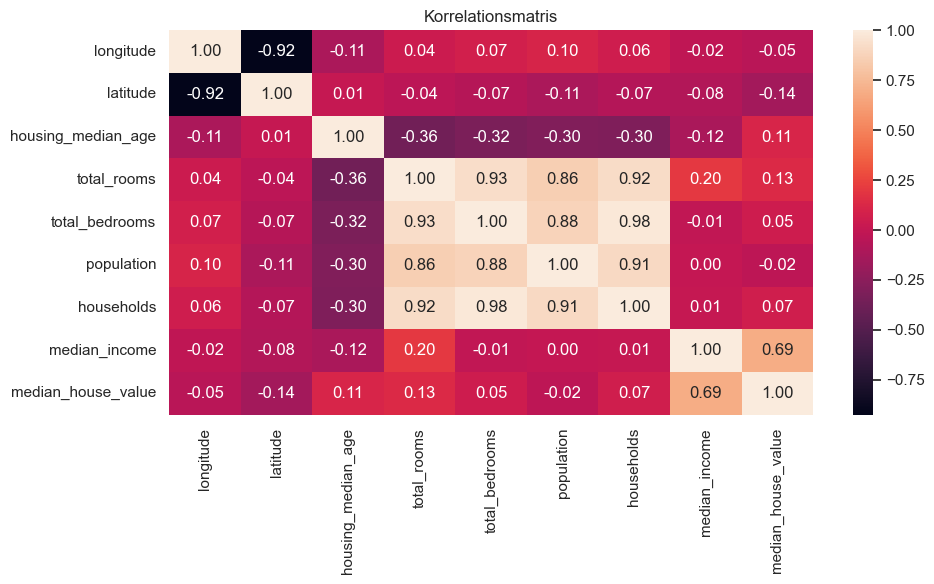

In [14]:
#Heatmap, från Regression videon, Omniway, Vecka 1, https://ec.omniway.se/exam/57484101

correlation_matrix = df.corr(numeric_only=True) #numeric_only=True för att exkludera ocean_proximity

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", ax=ax)
ax.set_title("Korrelationsmatris")
plt.tight_layout()
plt.show()

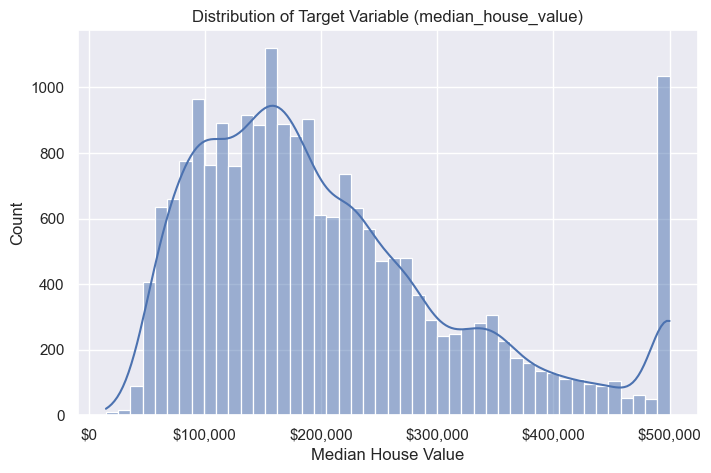

In [15]:
#Distributionsgraf, från Regression videon, Omniway, Vecka 1, https://ec.omniway.se/exam/57484101


plt.figure(figsize=(8, 5))
sns.histplot(y_full, kde=True)
plt.title("Distribution of Target Variable (median_house_value)")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))    #För att öka x-axelns läsbarhet
plt.show()

## Om datan 
Datasetet innehåller 20 640 rader och 10 kolumner. Nio av kolumnerna är numeriska och en (ocean_proximity) är kategorisk. Varje rad representerar ett område i Kalifornien.

Endast kolumnen total_bedrooms har saknade värden (207 stycken missing values). Dessa kommer hanteras med median-imputation i pipeline.

Heatmappen visar på korrelation mellan flera variablerna. Men för vår target / målvariabel median_house_value, så är den starkaste korrekationen med median_income.

Hisogrammet visar att distributionen är sne och att det finns outliners kring $500,000. Det kan finnas flera användingar till det, tex:

    - det finns områden med många hus kring en halv miljon dollar
    
    - datan hanterar alla hus på en halv mijon eller över som just $500,000. Dvs, det finns hus värda mer än $500,000 i datasettet men vi ser inte dem

